In [1]:
from idun_guardian_sdk import GuardianClient, FileTypes
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np

In [2]:


my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
my_recording_id = "1770724930729"


if __name__ == "__main__":
    client = GuardianClient(api_token=my_api_token)
    client.download_file(recording_id=my_recording_id, file_type=FileTypes.EEG)

[INFO] 2026-04-13 09:48:24,084: [API]: File saved: 'eeg_1770724930729.csv'


In [3]:
x = pd.read_csv("eeg_1770724930729.csv")

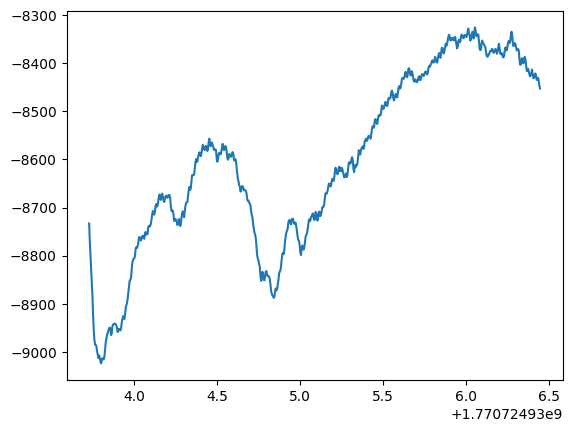

In [4]:
plt.plot(x["timestamp"], x["ch1"])

In [5]:
sos_hp = signal.iirdesign(wp=1, ws=0.5, gpass=1, gstop=40, analog=False, ftype="butter", output="sos", fs=250)
x_filt = signal.sosfilt(sos_hp, x['ch1'], zi=None)

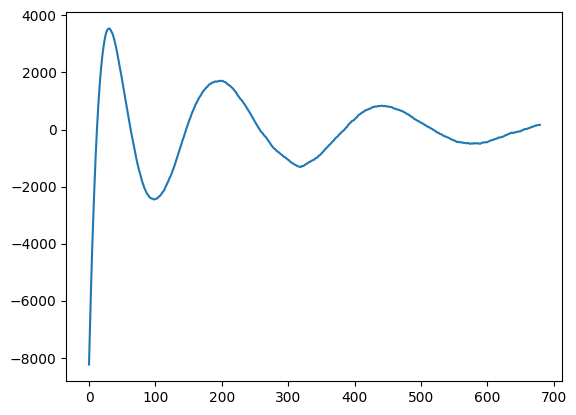

In [6]:
plt.plot(x_filt)

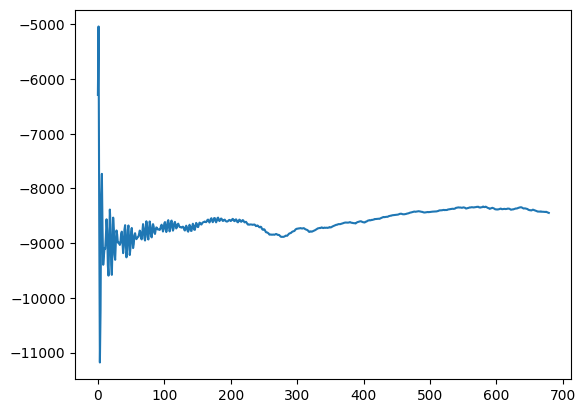

In [7]:
sos_notch = signal.iirdesign(wp=[46, 54], ws=[48, 52], gpass=1, gstop=60, analog=False, ftype='cheby2', output='sos', fs=250)
x_filt_cheby = signal.sosfilt(sos_notch, x['ch1'], zi=None)
plt.plot(x_filt_cheby)

In [8]:
"""
Sample script for using the Guardian Earbud Client

- Start recording data from the Guardian Earbuds
"""

import asyncio
from idun_guardian_sdk import GuardianClient

RECORDING_TIMER: int = 60 * 60 * 2  # 2 hours of recording
LED_SLEEP: bool = False

my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"


# Example callback function
def print_data(event):
    print("CB Func:", event.message)


if __name__ == "__main__":
    client = GuardianClient(api_token=my_api_token, debug=True)

    # Subscribe to live insights and/or realtime predictions
    client.subscribe_live_insights(raw_eeg=True, filtered_eeg=True, handler=print_data)
    client.subscribe_realtime_predictions(fft=True, jaw_clench=False, handler=print_data)

    # start a recording session
    asyncio.run(
        client.start_recording(
            recording_timer=RECORDING_TIMER, led_sleep=LED_SLEEP, calc_latency=False
        )
    )

RuntimeError: asyncio.run() cannot be called from a running event loop